In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def solve_riccati(T, Ndt, a, q, epslon, c, a_0, q_0, epslon_0, c_0, G):
    """
    Backward-Euler solve of both Riccati ODEs, VECTORIZED over an arbitrary
    batch dimension: every parameter may be a scalar (broadcasts across the
    batch) or an array-like of shape (N_sim,) -- e.g. evaluate phi/phi_0 at
    N_sim different (e.g. fitted-per-seed) parameter sets in one call
    instead of looping in Python.

    Minor bank phi_t  (eq 4.4): dphi/dt  = 2(a+q)*phi - phi^2 + epslon - q^2
    Major bank phi0_t (eq 4.2): dphi0/dt = 2*((a_0+q_0) + G*(a+q-phi_t))*phi0
                                            - phi0^2 + epslon_0 - q_0^2
    Terminal conditions: phi(T) = -c, phi0(T) = -c_0.

    returns (phi, phi_0), each shape (N_sim, Ndt+1) -- includes the terminal
    point at index Ndt; slice [:, :-1] to align with transition data (xt),
    matching solver.py's convention.
    """
    dt = T / Ndt

    a, q, epslon, c = (np.atleast_1d(np.asarray(x, dtype=float)) for x in (a, q, epslon, c))
    a_0, q_0, epslon_0, c_0, G = (np.atleast_1d(np.asarray(x, dtype=float))
                                    for x in (a_0, q_0, epslon_0, c_0, G))
    N_sim = max(x.size for x in (a, q, epslon, c, a_0, q_0, epslon_0, c_0, G))

    phi = np.zeros((N_sim, Ndt + 1))
    phi_0 = np.zeros((N_sim, Ndt + 1))

    phi[:, Ndt] = -c
    for k in range(Ndt - 1, -1, -1):
        phi_prev = phi[:, k + 1]
        dphi = 2 * (a + q) * phi_prev - phi_prev ** 2 + epslon - q ** 2
        phi[:, k] = phi_prev - dt * dphi

    phi_0[:, Ndt] = -c_0
    for k in range(Ndt - 1, -1, -1):
        phi0_prev = phi_0[:, k + 1]
        phi_t = phi[:, k + 1]
        dphi0 = (
            2 * ((a_0 + q_0) + G * (a + q - phi_t)) * phi0_prev
            - phi0_prev ** 2
            + epslon_0
            - q_0 ** 2
        )
        phi_0[:, k] = phi0_prev - dt * dphi0

    return phi, phi_0


In [3]:
A = 5
SIGMA_0, Q_0, EPSLON_0, C_0 = 1.0, 1.0, 10.0, 0.0
SIGMA, Q, EPSLON, C         = 1.0, 1.0, 1.5, 0.0
T, NDT   = 1, 512
N_BASE   = 256

phi_true,phi0_true = solve_riccati(
    T, NDT, a=A, q=Q, epslon=EPSLON, c=C,
    a_0=A*0.5, q_0=Q_0, epslon_0=EPSLON_0, c_0=C_0,
    G=0.5
)


In [4]:
# df = np.loadtxt('results_stage2_G_a_a0_Gtrue0.5.csv', delimiter=',',skiprows=1,usecols=(12,13,14))
# G_fit = df[:,0]
# a_fit = df[:,1]
# a0_fit = df[:,2]

# phi_fit,phi0_fit=solve_riccati(
#     T, NDT, a=a_fit, q=Q, epslon=EPSLON, c=C,
#     a_0=a0_fit, q_0=Q_0, epslon_0=EPSLON_0, c_0=C_0,
#     G=G_fit
# )

In [5]:
df = np.loadtxt('results_stage3_G_a_a0_q_q0_Gtrue0.5.csv', delimiter=',',skiprows=1,usecols=(14,15,16,17,18))
G_fit = df[:,0]
a_fit = df[:,1]
a0_fit = df[:,2]
q_fit = df[:,3]
q0_fit = df[:,4]

phi_fit,phi0_fit=solve_riccati(
    T, NDT, a=a_fit, q=q_fit, epslon=EPSLON, c=C,
    a_0=a0_fit, q_0=q0_fit, epslon_0=EPSLON_0, c_0=C_0,
    G=G_fit
)

In [12]:
np.mean((a_fit-A)**2)


1.488690804373893

In [13]:
np.mean((q_fit-Q)**2)


3.4503671261936812

In [14]:
np.mean((a_fit+q_fit-(A+Q))**2)

0.513903473245399

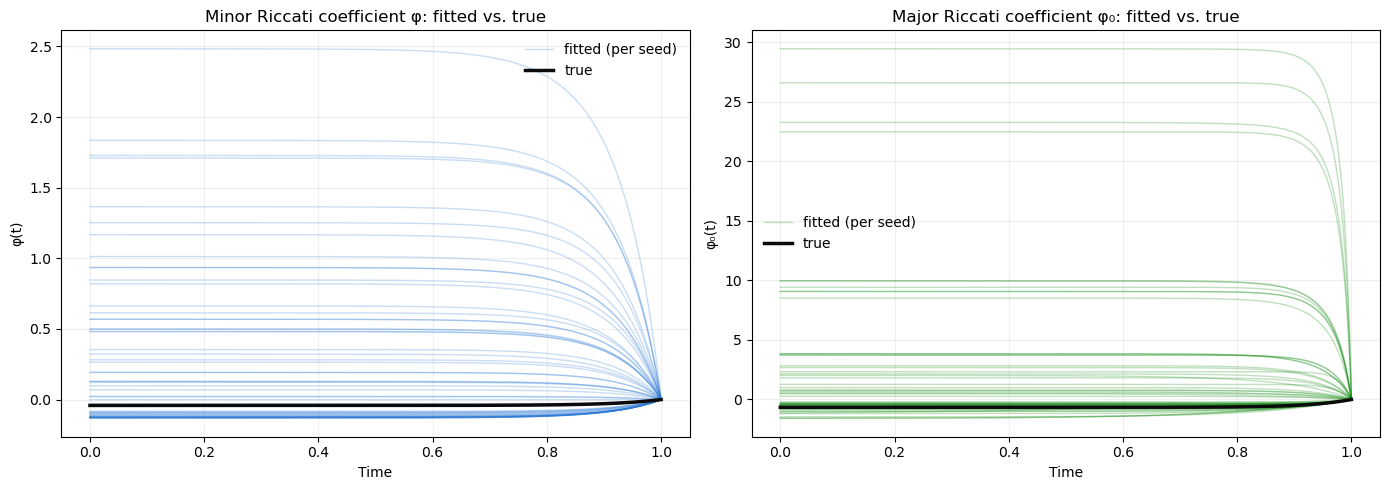

In [6]:
t_axis = np.linspace(0, T, phi_fit.shape[-1])
phi_true_curve  = np.asarray(phi_true).squeeze()
phi0_true_curve = np.asarray(phi0_true).squeeze()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- minor phi ---
ax = axes[0]
for i in range(phi_fit.shape[0]):
    ax.plot(t_axis, phi_fit[i], color='#2a78d6', alpha=0.25, linewidth=1,
             label='fitted (per seed)' if i == 0 else None)
ax.plot(t_axis, phi_true_curve, color='#0b0b0b', linewidth=2.5, label='true', zorder=10)
ax.set_xlabel('Time'); ax.set_ylabel('φ(t)')
ax.set_title('Minor Riccati coefficient φ: fitted vs. true')
ax.legend(loc='best', frameon=False)
ax.grid(True, alpha=0.2)

# --- major phi0 ---
ax = axes[1]
for i in range(phi0_fit.shape[0]):
    ax.plot(t_axis, phi0_fit[i], color='#008300', alpha=0.25, linewidth=1,
             label='fitted (per seed)' if i == 0 else None)
ax.plot(t_axis, phi0_true_curve, color='#0b0b0b', linewidth=2.5, label='true', zorder=10)
ax.set_xlabel('Time'); ax.set_ylabel('φ₀(t)')
ax.set_title('Major Riccati coefficient φ₀: fitted vs. true')
ax.legend(loc='best', frameon=False)
ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.show()


In [7]:
minor_mr_coef_true = A + Q - phi_true                          # (1, Ndt+1) or (Ndt+1,)
minor_mr_coef_fit  = a_fit[:, None] + Q - phi_fit               # (Nsim, Ndt+1)
major_mr_coef_true = A * 0.5 + Q_0 - phi0_true                  # (1, Ndt+1) or (Ndt+1,)
major_mr_coef_fit  = a0_fit[:, None] + Q_0 - phi0_fit           # (Nsim, Ndt+1)


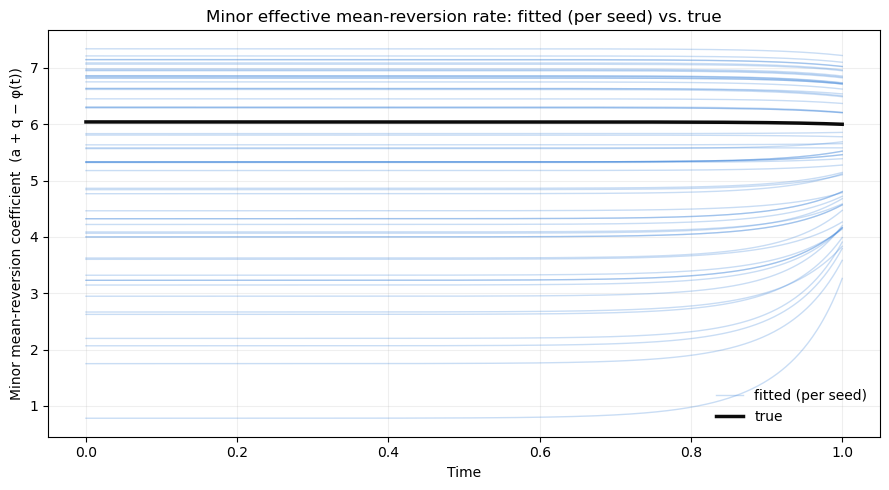

In [8]:


t_axis = np.linspace(0, T, minor_mr_coef_fit.shape[-1])
true_curve = np.asarray(minor_mr_coef_true).squeeze()   # collapses (1, Ndt+1) -> (Ndt+1,) if needed

fig, ax = plt.subplots(figsize=(9, 5))

# fitted: one thin, semi-transparent line per seed -- shows the spread
for i in range(minor_mr_coef_fit.shape[0]):
    ax.plot(t_axis, minor_mr_coef_fit[i], color='#2a78d6', alpha=0.25, linewidth=1,
             label='fitted (per seed)' if i == 0 else None)

# true: one bold reference line, drawn last so it sits on top
ax.plot(t_axis, true_curve, color='#0b0b0b', linewidth=2.5, label='true', zorder=10)

ax.set_xlabel('Time')
ax.set_ylabel('Minor mean-reversion coefficient  (a + q − φ(t))')
ax.set_title('Minor effective mean-reversion rate: fitted (per seed) vs. true')
ax.legend(loc='best', frameon=False)
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()


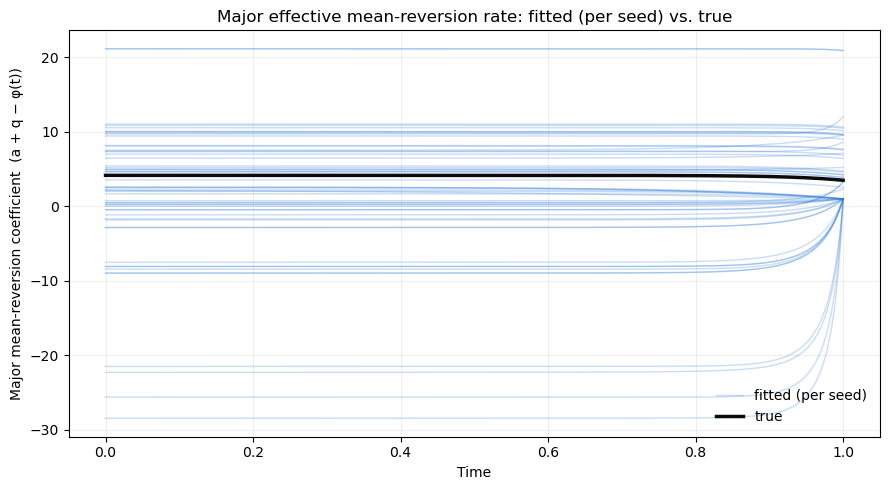

In [9]:


t_axis = np.linspace(0, T, major_mr_coef_fit.shape[-1])
true_curve = np.asarray(major_mr_coef_true).squeeze()   # collapses (1, Ndt+1) -> (Ndt+1,) if needed

fig, ax = plt.subplots(figsize=(9, 5))

# fitted: one thin, semi-transparent line per seed -- shows the spread
for i in range(major_mr_coef_fit.shape[0]):
    ax.plot(t_axis, major_mr_coef_fit[i], color='#2a78d6', alpha=0.25, linewidth=1,
             label='fitted (per seed)' if i == 0 else None)

# true: one bold reference line, drawn last so it sits on top
ax.plot(t_axis, true_curve, color='#0b0b0b', linewidth=2.5, label='true', zorder=10)

ax.set_xlabel('Time')
ax.set_ylabel('Major mean-reversion coefficient  (a + q − φ(t))')
ax.set_title('Major effective mean-reversion rate: fitted (per seed) vs. true')
ax.legend(loc='best', frameon=False)
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()